# Tutorial on Radar Cross Section (RCS)

This notebook introduces the radar cross section (RCS) module of Sionna RT.
Its central objects are sensing targets, i.e., scene objects whose scattering responses are described by scattering models rather than by radio materials. A scattering model consists of one or multiple scattering points, each with its own RCS. Besides integrated sensing and communication (ISAC), sensing targets are also useful to model objects with complex geometries for which ray tracing is ill-suited.

This notebook requires the full Sionna package, and not only Sionna RT, as it relies on Sionna PHY utilities to process and visualize the radar channel. The corresponding API documentation can be found [here](https://nvlabs.github.io/sionna/rt/api/rcs.html).

In this notebook, you will:
- Compute the radar channel of sensing targets with a constant RCS using the `RCSSolver`
- Visualize the radar channel in the range-velocity and angular domains
- Use the 3GPP TR 38.901 sensing targets, modeled by one or multiple scattering points
- Combine the sensing channel with the background channel computed by the `PathSolver`
- Apply basic radar processing in an urban scene with multiple moving cars

In [ ]:
# Import or install Sionna
# The full Sionna package, and not only Sionna RT, is required, as Sionna PHY
# utilities are used to process and visualize the radar channel.
try:
    import sionna.phy
except ImportError as e:
    # Only auto-install when the package itself is missing, not when a
    # transitive dependency fails to import.
    if getattr(e, "name", None) not in ("sionna", "sionna.phy"):
        raise
    import os
    import sys
    if "google.colab" in sys.modules:
        # Install Sionna in Google Colab
        print("Installing Sionna and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna")
        os.kill(os.getpid(), 5)
    else:
        raise e

%matplotlib inline
import matplotlib.pyplot as plt

import mitsuba as mi
import numpy as np
import drjit as dr
import torch
from scipy.constants import speed_of_light

from sionna import rt
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera
from sionna.rt.rcs import RCSSolver, TR38901SensingTarget, ConstantRCSSensingTarget
from sionna.phy.channel import cir_to_ofdm_channel, ofdm_to_delay_doppler_channel,\
                               subcarrier_frequencies
from sionna.phy.isac import plot_delay_doppler, plot_angular_scan, steering_vectors,\
                           angular_delay_doppler_spectrum
from sionna.phy.signal import HannWindow

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

## Getting started
We consider an empty scene with co-located transmitter and receiver, i.e., a monostatic sensing setup.
Both transmitter and receiver have a single isotropic antenna, and the sensing target has a constant RCS $\sigma$ that preserves polarization.

We compute the radar channel using the ``RCSSolver``, compare the received power against the radar equation, and visualize the radar channel in the range-velocity domain.

The general radar equation is given as follows:

$$
P_r = P_t \frac{G_t G_r \lambda^2 \sigma}{(4\pi)^3 R_t^2 R_r^2}
$$
where $G_t, G_r$ are the gains of the transmit and receive antennas, $R_t, R_r$ are the distances between the target and the transmitter and receiver, and $P_t, P_r$ are the transmit and received powers, respectively.

For a monostatic setup with unit-gain antennas, this simplifies to
$$
P_r = P_t \frac{\lambda^2 \sigma}{(4\pi)^3 R_t^4}.
$$

For a monostatic radar, the Doppler shift caused by a target moving with radial velocity $v_r$ is
$$
f_D = -\frac{2v_r}{\lambda},
$$
where the radial velocity is the projection of the target velocity $\mathbf{v}$ onto the direction from the radar to the target:
$$
v_r = \mathbf{v}^\mathsf{T}\hat{\mathbf{r}}, \qquad
\hat{\mathbf{r}} = \frac{\mathbf{p}_{\mathrm{target}}-\mathbf{p}_{\mathrm{radar}}}{\left\|\mathbf{p}_{\mathrm{target}}-\mathbf{p}_{\mathrm{radar}}\right\|}.
$$
With Sionna RT's sign convention, a receding target ($v_r>0$) produces a negative Doppler shift, while an approaching target produces a positive one.
Following the radar convention, the range-velocity maps shown in this notebook display the velocity $-v_r$, which is positive for approaching targets.

In [2]:
scene = load_scene()
scene.frequency = 3.5e9

# Create a monostatic sensing setup with co-located transmitter and receiver
radar_position = np.array([0, 0, 0])
scene.add(Transmitter("tx", position=radar_position))
scene.add(Receiver("rx", position=radar_position))

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             polarization="V",
                             pattern="iso")
scene.rx_array = scene.tx_array

# Create a target with constant RCS, approaching the radar at 100 m/s
sigma = 3.0 # m^2
target1 = ConstantRCSSensingTarget("st-1",
                                   sigma=sigma,
                                   position=(0, 0, 100),
                                   velocity=(0, 0, -100))
scene.add(target1)

# Compute the radar channel
rcs_solver = RCSSolver()
paths = rcs_solver(scene, max_depth=1)

# Received power and distance of the target obtained with Sionna RT.
# As the transmit power and the antenna gains are equal to one, the received
# power is the squared magnitude of the path coefficient.
a, tau = paths.cir(out_type="numpy", normalize_delays=False)
rt_power = np.abs(np.squeeze(a))**2
rt_distance = np.squeeze(tau)*speed_of_light/2

# Expected received power and distance
wavelength = scene.wavelength.numpy()[0]
distance = np.linalg.norm(target1.position.numpy()[:, 0] - radar_position)
expected_power = sigma*wavelength**2/((4*np.pi)**3*distance**4)

print(f"{'':16}{'Sionna RT':>12}{'Expected':>12}")
print(f"{'Received power':16}{rt_power:12.3E}{expected_power:12.3E}")
print(f"{'Distance [m]':16}{rt_distance:12.2f}{distance:12.2f}")

                   Sionna RT    Expected
Received power     1.109E-13   1.109E-13
Distance [m]          100.00      100.00


Next, we visualize the target in the range-velocity domain. The function below generates a time sequence of channel impulse responses (CIRs) from the Doppler shifts of the paths, computes the corresponding OFDM channel frequency responses, and transforms them to the delay-Doppler domain. The helper `expected_range_velocity()` computes the expected range and radial velocity of the targets, which are shown as red markers.

In [3]:
def expected_range_velocity(targets, radar_position):
    """Compute the range and radial velocity of targets seen by a monostatic radar.

    :param targets: List of sensing targets.
    :param radar_position: Position of the radar [m].
    :return: List of ``(range_m, radial_velocity_mps)`` tuples. The radial
        velocity is positive for a receding target.
    """
    points = []
    for target in targets:
        radial_vector = target.position.numpy()[:, 0] - radar_position
        target_range = np.linalg.norm(radial_vector)
        radial_velocity = np.dot(target.velocity.numpy()[:, 0],
                                 radial_vector/target_range)
        points.append((target_range, radial_velocity))
    return points

def plot_range_velocity(paths, wavelength, expected_points=None):
    """Plot the channel power in the range-velocity domain.

    :param paths: Paths for which to compute the range-velocity map.
    :param wavelength: Carrier wavelength [m].
    :param expected_points: Optional list of ``(range_m, radial_velocity_mps)``
        points to display as red markers. The radial velocity is positive for
        a receding target.
    """
    subcarrier_spacing = 30e3
    num_subcarriers = 512
    num_time_steps = 200
    num_delay_bins = 32 # Only the first delay bins are shown
    bandwidth = num_subcarriers*subcarrier_spacing
    sampling_frequency = subcarrier_spacing # One sample per OFDM symbol

    # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    a, tau = paths.cir(sampling_frequency=sampling_frequency,
                       num_time_steps=num_time_steps,
                       normalize_delays=False,
                       out_type="torch")

    # Sionna PHY expects a leading batch dimension
    frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
    h_f = cir_to_ofdm_channel(frequencies, a[None], tau[None])
    h_f = h_f[0, 0, 0, 0, 0] # [time, freq]
    h_dd = ofdm_to_delay_doppler_channel(h_f, l_max=num_delay_bins-1) # [doppler, delay]

    _, ax = plt.subplots(figsize=(8, 5))
    plot_delay_doppler(h_dd.abs().square(),
                       fast_time_sample_rate=bandwidth,
                       slow_time_sample_rate=sampling_frequency,
                       wavelength=wavelength,
                       domain="range_velocity",
                       ax=ax)
    if expected_points:
        points = np.asarray(expected_points, dtype=float)
        # The map shows the closing velocity, i.e., minus the radial velocity
        ax.scatter(points[:, 0], -points[:, 1], color="red",
                   marker="x", s=80, label="Expected target")
        ax.legend()

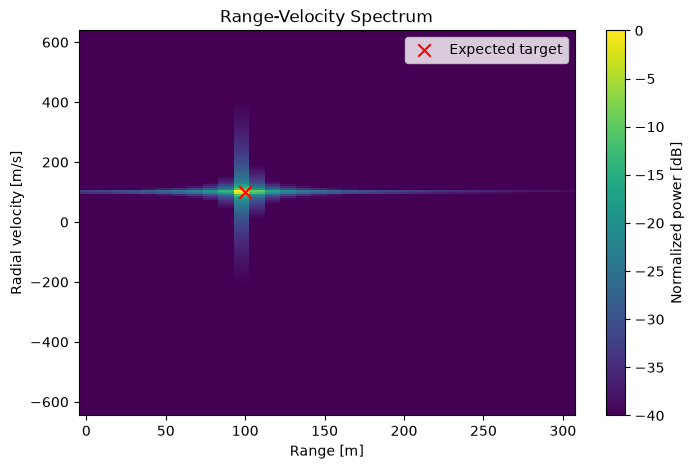

In [4]:
plot_range_velocity(paths, wavelength,
                    expected_range_velocity([target1], radar_position))

## Sensing with multiple targets

We now extend the previous scenario with two more targets, cloned from the first one, and move all three targets so that they are observed at different ranges and velocities.

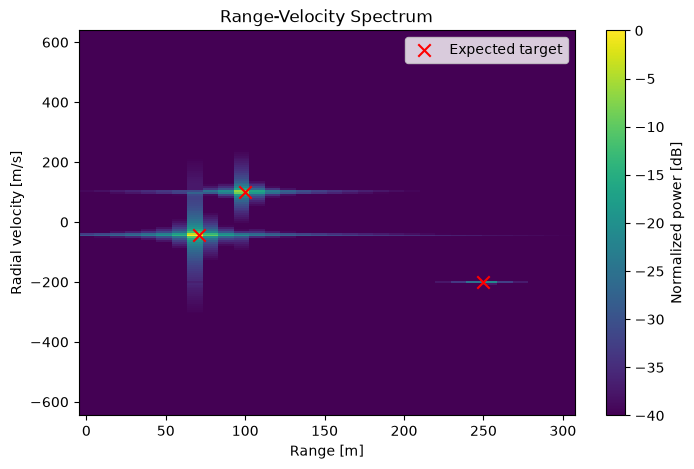

In [5]:
# Add new targets if they do not already exist
if scene.get("st-2") is None:
    target2 = target1.clone("st-2")
    target3 = target1.clone("st-3")
    scene.add([target2, target3]) # Batch add for efficiency

# Set positions and velocities
target1.position = mi.Point3f(0, 0, -100)
target1.velocity = mi.Vector3f(0, 0, 100)

target2.position = mi.Point3f(0, 50, 50)
target2.velocity = mi.Vector3f(0, 30, 30)

target3.position = mi.Point3f(0, 250, 0)
target3.velocity = mi.Vector3f(0, 200, 0)

paths = rcs_solver(scene, max_depth=1)

targets = [target1, target2, target3]
plot_range_velocity(paths, wavelength,
                    expected_range_velocity(targets, radar_position))

## Sensing with antenna arrays
In this section, we use multiple receive antennas to locate targets in the angular domain. The receiver is equipped with a $16\times 16$ planar array, while the transmitter keeps a single antenna.

In [6]:
scene = load_scene()
scene.frequency = 3.5e9

# Create a monostatic sensing setup with co-located transmitter and receiver
radar_position = np.array([0, 0, 0])
scene.add(Transmitter("tx", position=radar_position))
scene.add(Receiver("rx", position=radar_position))

# The receiver array is a 16x16 grid of antennas
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             polarization="V",
                             pattern="iso")
scene.rx_array = PlanarArray(num_rows=16,
                             num_cols=16,
                             polarization="V",
                             pattern="iso")

# Create two targets with constant RCS
target1 = ConstantRCSSensingTarget("st-1",
                                   sigma=3.0,
                                   position=(100, 100, 100))
target2 = target1.clone("st-2")
target2.position = (40, -50, -20)
scene.add([target1, target2])

# Compute the radar channel
rcs_solver = RCSSolver()
paths = rcs_solver(scene, max_depth=1)

The function below computes an angular spectrum by correlating the channel observed across the receive antennas with steering vectors for a grid of azimuth and zenith angles. The peaks of the spectrum indicate the directions of the targets.

In [7]:
def plot_angular_spectrum(paths, rx_array, expected_points=None):
    """Plot the channel power in the joint azimuth-zenith domain.

    The channel is evaluated at the carrier frequency. The receiver array is
    assumed to have its default orientation, with broadside along the positive
    x-axis.

    :param paths: Paths for which to compute the angular spectrum.
    :param rx_array: Planar receiver antenna array.
    :param expected_points: Optional list of ``(azimuth_deg, elevation_deg)``
        points to display as red markers.
    """
    num_angles = 181
    theta = torch.deg2rad(torch.linspace(0., 180., num_angles))   # zenith
    phi = torch.deg2rad(torch.linspace(-90., 90., num_angles))    # azimuth

    # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, 1]
    a, tau = paths.cir(normalize_delays=False, out_type="torch")

    # At zero baseband frequency, delays do not affect the array response.
    # Sionna PHY expects a leading batch dimension.
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, 1, 1]
    h = cir_to_ofdm_channel(torch.zeros(1), a[None], tau[None])[0]

    # Array positions are normalized by wavelength, hence wavelength=1
    positions = torch.as_tensor(rx_array.normalized_positions.numpy().T)
    rx_steering = steering_vectors(positions, theta, phi, wavelength=1.)
    rx_steering = rx_steering.reshape(-1, positions.shape[0])
    tx_steering = torch.ones(1, 1, dtype=rx_steering.dtype) # Single TX antenna

    spectrum = angular_delay_doppler_spectrum(h, rx_steering, tx_steering)
    spectrum = spectrum.reshape(num_angles, num_angles)

    _, ax = plt.subplots(figsize=(7, 6))
    plot_angular_scan(spectrum, theta, phi, ax=ax)
    ax.invert_yaxis() # Zenith 0 (straight up) at the top
    if expected_points:
        points = np.asarray(expected_points, dtype=float)
        # The map shows the zenith angle, i.e., 90 deg minus the elevation
        ax.scatter(points[:, 0], 90 - points[:, 1], color="red",
                   marker="x", s=80, label="Expected target")
        ax.legend()

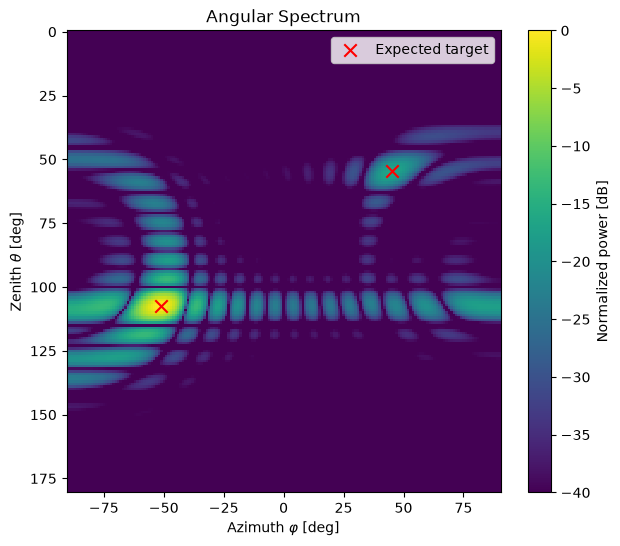

In [8]:
# Expected azimuth and elevation angles of the targets
expected_angles = []
for target in [target1, target2]:
    radial_vector = target.position.numpy()[:, 0] - radar_position
    elevation = np.rad2deg(np.arctan2(radial_vector[2],
                                      np.linalg.norm(radial_vector[:2])))
    azimuth = np.rad2deg(np.arctan2(radial_vector[1], radial_vector[0]))
    expected_angles.append((azimuth, elevation))

plot_angular_spectrum(paths, scene.rx_array, expected_angles)

## Sensing with multipath and background channel

The `RCSSolver` only computes the paths that interact with a sensing target, i.e., the sensing channel. The paths that do not interact with any sensing target, i.e., the background channel, are computed with the `PathSolver`. Both sets of paths can be combined with `Paths.concat()`.

We consider a bistatic setup in a street canyon with a large UAV target as defined in 3GPP TR 38.901. In contrast to the empty scene used above, the sensing channel can now have multipath components. The maximum number of interactions of a ray with the scene is controlled by the parameter `max_depth` (where a value of one corresponds to line-of-sight only). You can also configure which type of interactions are permitted, namely line-of-sight, reflection and refraction. Due to the high pathloss of the radar channel, diffraction is not considered as it would lead to many paths with very little energy.

In [9]:
scene = load_scene(rt.scene.simple_street_canyon)
scene.frequency = 3.5e9
scene.add(Transmitter("tx", position=[34, -10, 30]))
scene.add(Receiver("rx", position=[34, 11.5, 22.5]))
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             polarization="V",
                             pattern="iso")
scene.rx_array = scene.tx_array

# Large UAV with a single scattering point, as defined in 3GPP TR 38.901
target = TR38901SensingTarget(name="target",
                              object_type="uav-large-size",
                              model_type=2,
                              position=[0, 0, 50],
                              velocity=[0, 10, 0])
scene.add(target)

# Sensing channel computed by the RCS solver, and background channel
# computed by the path solver
rcs_solver = RCSSolver()
background_solver = PathSolver()

sensing_paths = rcs_solver(scene,
                           max_depth=5,
                           los=True,
                           specular_reflection=True,
                           refraction=False)

background_paths = background_solver(scene,
                                     max_depth=5,
                                     los=True,
                                     specular_reflection=True,
                                     refraction=True,
                                     diffraction=True)

all_paths = background_paths.concat(sensing_paths)

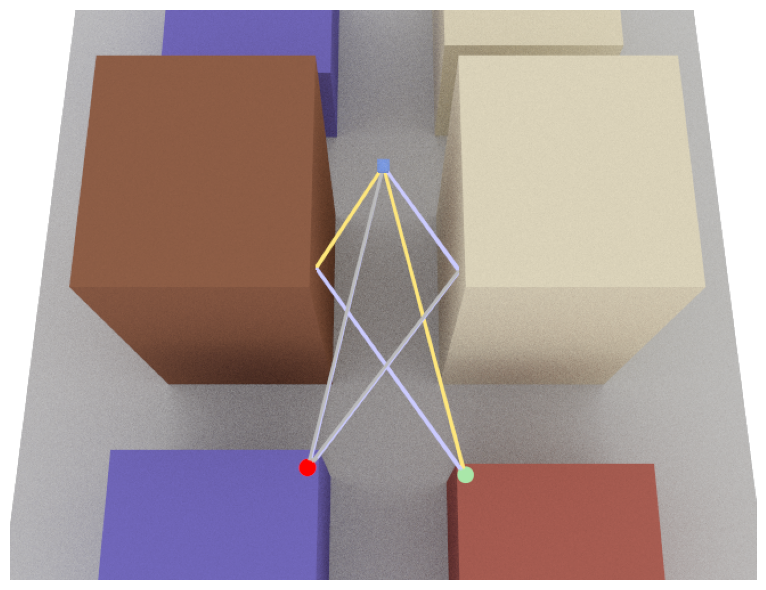

In [10]:
# Visualize the scene and the sensing paths
if no_preview:
    cam = Camera(position=[50, 0, 150], look_at=[0, 0, 0])
    scene.render(camera=cam, paths=sensing_paths);
    # scene.render(camera=cam, paths=background_paths) # Uncomment to visualize the background paths
    # scene.render(camera=cam, paths=all_paths) # Uncomment to visualize all paths
else:
    scene.preview(paths=sensing_paths)
    # scene.preview(paths=background_paths) # Uncomment to visualize the background paths
    # scene.preview(paths=all_paths) # Uncomment to visualize all paths

The next cell compares the channel impulse responses of the background and sensing channels.

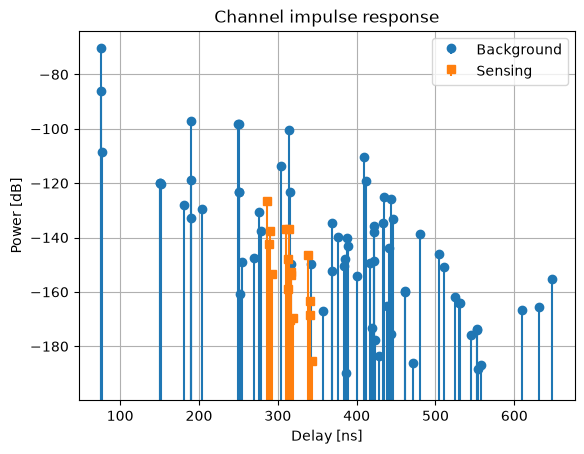

In [11]:
a_bg, tau_bg = background_paths.cir(out_type="numpy", normalize_delays=False)
a_bg = np.squeeze(a_bg)
tau_bg = np.squeeze(tau_bg)

a_sens, tau_sens = sensing_paths.cir(out_type="numpy", normalize_delays=False)
a_sens = np.squeeze(a_sens)
tau_sens = np.squeeze(tau_sens)

power_bg_db = 10.0*np.log10(np.abs(a_bg)**2)
power_sens_db = 10.0*np.log10(np.abs(a_sens)**2)
floor_db = min(power_bg_db.min(), power_sens_db.min()) - 10.0

plt.figure()
plt.stem(tau_bg*1e9, power_bg_db, bottom=floor_db,
         linefmt="C0-", markerfmt="C0o", basefmt=" ", label="Background")
plt.stem(tau_sens*1e9, power_sens_db, bottom=floor_db,
         linefmt="C1-", markerfmt="C1s", basefmt=" ", label="Sensing")
plt.ylim(bottom=floor_db)
plt.xlabel("Delay [ns]")
plt.ylabel("Power [dB]")
plt.title("Channel impulse response")
plt.legend()
plt.grid(True)

## Multiple scattering points on a sensing target
Sionna RT supports scattering models with multiple scattering points, as shown in the next cells for a vehicle modeled by five scattering points according to 3GPP TR 38.901.

Note that sensing targets are scene objects with an associated mesh. The scattering response of a target is entirely determined by its scattering model, i.e., its own mesh does not affect it. However, the mesh acts as an absorber for all other paths: any ray of the background channel intersecting it is discarded, and it can shadow the scattering points of other targets or block the legs of their sensing paths.

In [12]:
scene = load_scene(rt.scene.simple_street_canyon)
scene.frequency = 3.5e9
scene.add(Transmitter("tx", position=[25, 0, 1.5]))
scene.add(Receiver("rx", position=[-25, 0, 1.5]))
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             polarization="V",
                             pattern="iso")
scene.rx_array = scene.tx_array

# Vehicle modeled by multiple scattering points, as defined in 3GPP TR 38.901.
# As neither dimensions nor a mesh are specified, the target size defaults to
# the one of the TR 38.901 specifications. Setting the dimensions overrides
# these defaults, while providing a mesh uses the dimensions of its bounding box.
target = TR38901SensingTarget(name="target",
                              fname=rt.scene.low_poly_car,
                              object_type="vehicle-multi-sp",
                              model_type=2,
                              position=[0, 0, 0.8],
                              velocity=[15, 10, 0])
scene.add(target)

rcs_solver = RCSSolver()
background_solver = PathSolver()

sensing_paths = rcs_solver(scene,
                           max_depth=5,
                           los=True,
                           specular_reflection=True,
                           refraction=False)

background_paths = background_solver(scene,
                                     max_depth=5,
                                     los=True,
                                     specular_reflection=True,
                                     refraction=False,
                                     diffraction=False)

all_paths = background_paths.concat(sensing_paths)

Before visualizing the computed paths, let's first examine the multi-point scattering model applied to the sensing target.
This can be done using the `show()` method of the `TR38901SensingTarget` object.
Please note that this utility opens an interactive window, and can only be used when preview is enabled (`no_preview = False`).

In [13]:
if not no_preview:
    target.show(k_i = dr.normalize(mi.Vector3f(-1, 1, -1)))

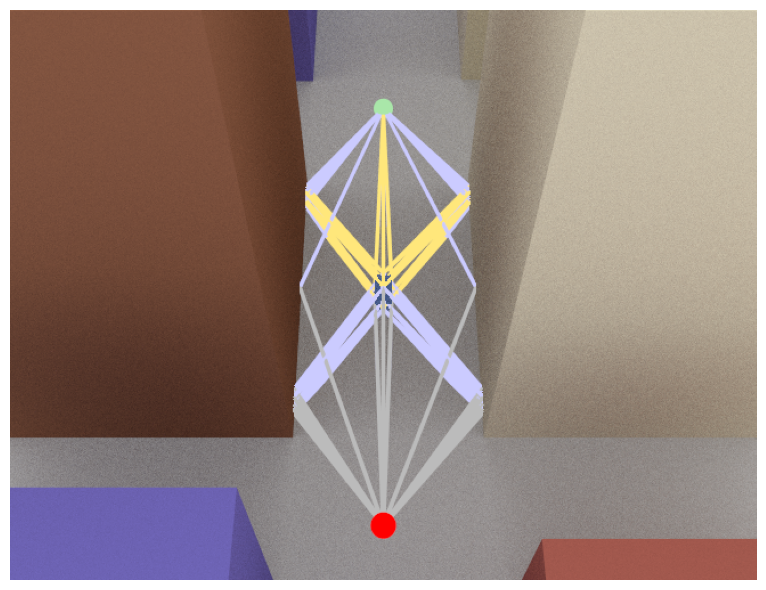

In [14]:
# No path of the background channel goes through the sensing target
if no_preview:
    cam = Camera(position=[50, 0, 80], look_at=[0, 0, 0])
    scene.render(camera=cam, paths=all_paths);
    # scene.render(camera=cam, paths=sensing_paths) # Uncomment to visualize the sensing paths
    # scene.render(camera=cam, paths=background_paths) # Uncomment to visualize the background paths
else:
    scene.preview(paths=all_paths)
    # scene.preview(paths=sensing_paths) # Uncomment to visualize the sensing paths
    # scene.preview(paths=background_paths) # Uncomment to visualize the background paths

## Urban scene with multiple TR 38.901 sensing targets

We now consider a more realistic scenario in the Etoile scene. A monostatic radar operating at 28 GHz is mounted on an 8 m mast along one of the avenues and looks at the Arc de Triomphe. Twenty cars drive on the roundabout and along the avenue. Each car is a TR 38.901 vehicle with multiple scattering points, and uses a low-poly car mesh.

In [15]:
scene = load_scene(rt.scene.etoile)
scene.frequency = 28e9

# 'Etoile' scene: centre of the Arc de Triomphe and one of its avenues
arc = np.array([-127.4, 38.1])
avenue_azimuth = np.deg2rad(119.)
along = np.array([np.cos(avenue_azimuth), np.sin(avenue_azimuth)]) # Away from the Arc
across = np.array([-along[1], along[0]])

# Monostatic radar on an 8 m mast, 210 m down the avenue, looking at the Arc
radar_distance = 210. # Distance from the Arc [m]
radar_position = np.append(arc + radar_distance*along, 8.)
boresight = mi.Point3f(float(arc[0]), float(arc[1]), 2.)
scene.add(Transmitter("tx", position=radar_position, look_at=boresight,
                      color=(0.95, 0.15, 0.05), display_radius=1.2))
scene.add(Receiver("rx", position=radar_position, look_at=boresight,
                   color=(0.95, 0.15, 0.05), display_radius=1.2))
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             polarization="V",
                             pattern="iso")
scene.rx_array = scene.tx_array

# Traffic lanes: a ring on the roundabout, and a loop down the avenue made of
# two opposing lanes closed by a U-turn at each end
ring_radius, lane_offset = 62., 8.
angles = np.linspace(0., 2*np.pi, 72, endpoint=False)
ring = arc + ring_radius*np.stack([np.cos(angles), np.sin(angles)], axis=1)

near, far = ring_radius + 48., radar_distance - 6.
reach = np.linspace(near, far, 40)[:, None]
turn = np.linspace(0., np.pi, 12)[1:-1, None]
avenue = np.vstack([
    arc + along*reach + across*lane_offset,
    arc + along*far + lane_offset*(np.cos(turn)*across + np.sin(turn)*along),
    arc + along*reach[::-1] - across*lane_offset,
    arc + along*near - lane_offset*(np.cos(turn)*across + np.sin(turn)*along)])

def car_states(lane, num_cars, speed):
    """Spread cars evenly along a closed lane.

    :param lane: Vertices of the closed lane, shape [num_vertices, 2].
    :param num_cars: Number of cars on the lane.
    :param speed: Speed of the cars [m/s].
    :return: Iterator over the ``(position, heading, velocity)`` of each car,
        where ``position`` and ``velocity`` are 2D vectors and ``heading`` is
        the yaw angle [rad].
    """
    steps = np.diff(np.vstack([lane, lane[:1]]), axis=0)
    lengths = np.linalg.norm(steps, axis=1)
    cumulative = np.concatenate([[0.], np.cumsum(lengths)])
    s = np.linspace(0., cumulative[-1], num_cars, endpoint=False)
    i = np.searchsorted(cumulative, s, side="right") - 1
    forward = steps[i]/lengths[i, None]
    positions = lane[i] + forward*(s - cumulative[i])[:, None]
    headings = np.arctan2(forward[:, 1], forward[:, 0])
    return zip(positions, headings, forward*speed)

# Cars modeled by multiple scattering points, driving at 12 m/s on the avenue
# and at 9 m/s on the ring
num_cars_per_lane = 10
fleet = []
for lane_index, (lane, speed) in enumerate([(avenue, 12.), (ring, 9.)]):
    for car_index, state in enumerate(car_states(lane, num_cars_per_lane, speed)):
        car = TR38901SensingTarget(f"car-{lane_index}-{car_index}",
                                   object_type="vehicle-multi-sp",
                                   model_type=2,
                                   fname=rt.scene.low_poly_car,
                                   display_opacity=1.)
        fleet.append((car, state))

cars = [car for car, _ in fleet]
scene.add(cars) # A single scene edit for the whole fleet
for car, (position, heading, velocity) in fleet:
    car.position = mi.Point3f(float(position[0]), float(position[1]), 0.8)
    car.orientation = mi.Point3f(float(heading), 0., 0.)
    car.velocity = mi.Vector3f(float(velocity[0]), float(velocity[1]), 0.)

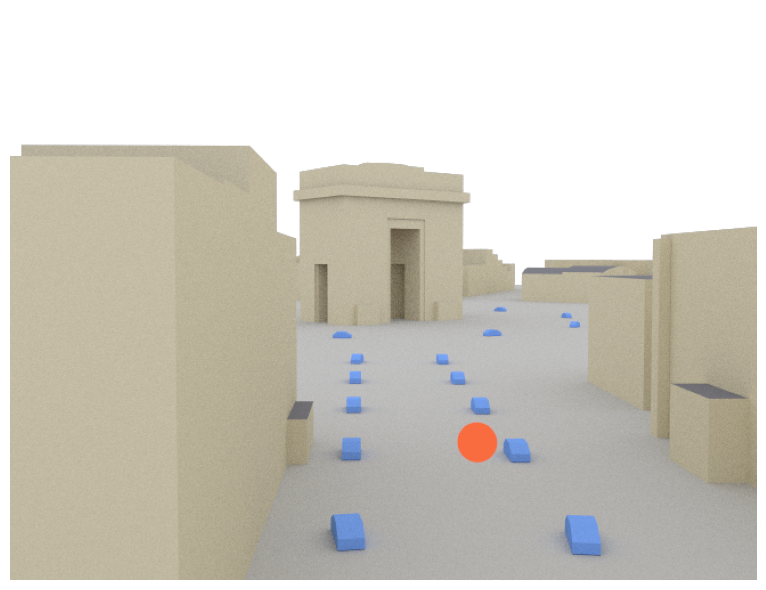

In [16]:
# Visualize the scene
if no_preview:
    camera_position = np.append(radar_position[:2] + 48.*along - 7.*across, 19.)
    cam = Camera(position=camera_position.tolist(),
                 look_at=np.append(arc, 8.).tolist())
    scene.render(camera=cam, fov=50); # Paths are too many to render
else:
    scene.preview()

We now compute three channels: the line-of-sight (LoS) only sensing channel, for which both legs of every sensing path are unobstructed (`max_depth=1`); the multi-bounce sensing channel, whose legs can also be reflected or refracted by the environment (`max_depth=5`); and the multi-bounce sensing channel combined with the background channel.

In [17]:
rcs_solver = RCSSolver()
background_solver = PathSolver()

sensing_paths_los_only = rcs_solver(scene,
                                    max_depth=1,
                                    samples_per_sp=200_000,
                                    buffer_size_per_sp=200_000,
                                    los=True,
                                    specular_reflection=True,
                                    refraction=True,
                                    seed=1234)

sensing_paths_multi_bounce = rcs_solver(scene,
                                        max_depth=5,
                                        samples_per_sp=200_000,
                                        buffer_size_per_sp=200_000,
                                        los=True,
                                        specular_reflection=True,
                                        refraction=True,
                                        seed=1234)

# A monostatic radar does not hear itself, hence no LoS path
background_paths = background_solver(scene,
                                     max_depth=5,
                                     samples_per_src=2_000_000,
                                     max_num_paths_per_src=2_000_000,
                                     los=False,
                                     specular_reflection=True,
                                     diffuse_reflection=False,
                                     refraction=True,
                                     diffraction=False,
                                     seed=1234)

sensing_paths_with_background = background_paths.concat(sensing_paths_multi_bounce)

# Channels to visualize, keyed by the title of their range-velocity map
channels = {"LoS-only sensing channel": sensing_paths_los_only,
            "Multi-bounce sensing channel": sensing_paths_multi_bounce,
            "Sensing and background channel": sensing_paths_with_background}

The function below plots the range-velocity maps of the three channels. Two optional processing steps, enabled through dedicated flags, improve the detectability of the targets:
* **Hann windowing**: A Hann window is applied across subcarriers and across soundings before the transform to the delay-Doppler domain, which reduces the sidelobes of strong targets.
* **Path loss compensation**: The power of each range bin is scaled by $R^4$ to compensate for the two-way spreading loss, so that distant targets remain visible.

The red squares indicate the expected range and velocity of each car, computed from the position and velocity of its center.

In [18]:
def plot_range_velocity_maps(channels, wavelength, expected_points=None,
                             apply_hann_window=False,
                             apply_pathloss_compensation=False):
    """Plot the range-velocity maps of several channels side by side.

    :param channels: Dictionary mapping the title of each map to the paths of
        the corresponding channel.
    :param wavelength: Carrier wavelength [m].
    :param expected_points: Optional list of ``(range_m, radial_velocity_mps)``
        points to display as red squares. The radial velocity is positive for
        a receding target.
    :param apply_hann_window: If `True`, a Hann window is applied across
        subcarriers and soundings.
    :param apply_pathloss_compensation: If `True`, the power of each range bin
        is scaled by :math:`R^4` to compensate for the two-way spreading loss.
    """
    subcarrier_spacing = 120e3
    num_subcarriers = 1024
    num_time_steps = 256
    prf = 10e3         # Soundings per second, sets the velocity span
    min_range = 20.    # Smallest range shown [m], hides the ground bounce below the mast
    max_range = 320.   # Largest range shown [m]
    max_velocity = 22. # Largest closing velocity shown [m/s]
    bandwidth = num_subcarriers*subcarrier_spacing
    range_resolution = speed_of_light/(2*bandwidth)
    l_min = int(np.ceil(min_range/range_resolution))
    l_max = int(max_range/range_resolution)
    frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

    _, axs = plt.subplots(1, len(channels), figsize=(8*len(channels), 5),
                          squeeze=False)
    for ax, (title, paths) in zip(axs[0], channels.items()):
        # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
        a, tau = paths.cir(sampling_frequency=prf,
                           num_time_steps=num_time_steps,
                           normalize_delays=False,
                           out_type="torch")

        # Sionna PHY expects a leading batch dimension
        h_f = cir_to_ofdm_channel(frequencies, a[None], tau[None])
        h_f = h_f[0, 0, 0, 0, 0] # [time, freq]

        if apply_hann_window:
            h_f = HannWindow()(h_f)     # Across subcarriers
            h_f = HannWindow()(h_f.T).T # Across soundings

        h_dd = ofdm_to_delay_doppler_channel(h_f, l_min=l_min, l_max=l_max) # [doppler, delay]
        power = h_dd.abs().square()

        if apply_pathloss_compensation:
            ranges = torch.arange(l_min, l_max + 1, device=power.device)*range_resolution
            power = power*ranges**4

        plot_delay_doppler(power,
                           l_min=l_min,
                           fast_time_sample_rate=bandwidth,
                           slow_time_sample_rate=prf,
                           wavelength=wavelength,
                           domain="range_velocity",
                           db_floor=-45.,
                           ax=ax)
        if expected_points:
            points = np.asarray(expected_points, dtype=float)
            # The maps show the closing velocity, i.e., minus the radial velocity
            ax.scatter(points[:, 0], -points[:, 1], marker="s", s=20,
                       facecolors="none", edgecolors="red", label="Car")
            ax.legend(loc="upper right")
        # Markers outside of the displayed window must not extend the axes
        ax.set(xlim=(min_range, max_range),
               ylim=(-max_velocity, max_velocity),
               title=title)

Let's first visualize the three channels without any additional processing:

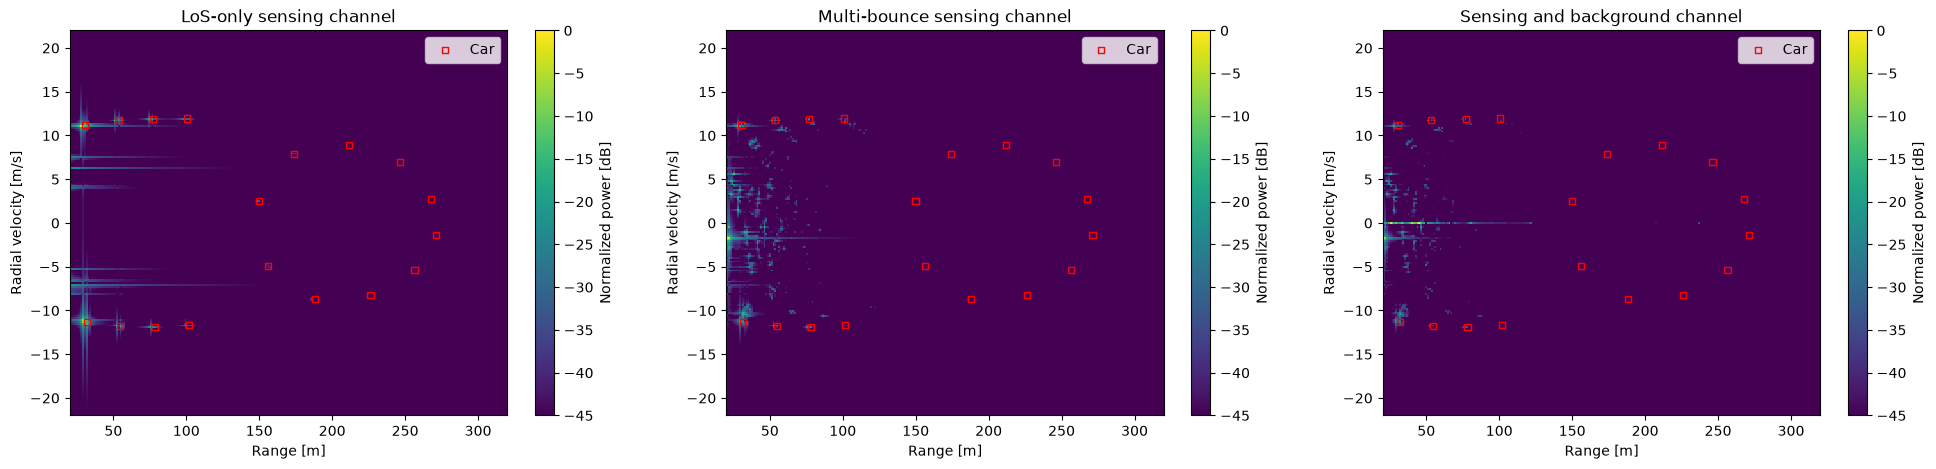

In [19]:
wavelength = scene.wavelength.numpy()[0]
car_points = expected_range_velocity(cars, radar_position)

plot_range_velocity_maps(channels, wavelength, car_points)

Strong targets smear across the maps because of the high sidelobes of the implicit rectangular window of the Fourier transform. A Hann window reduces these sidelobes:

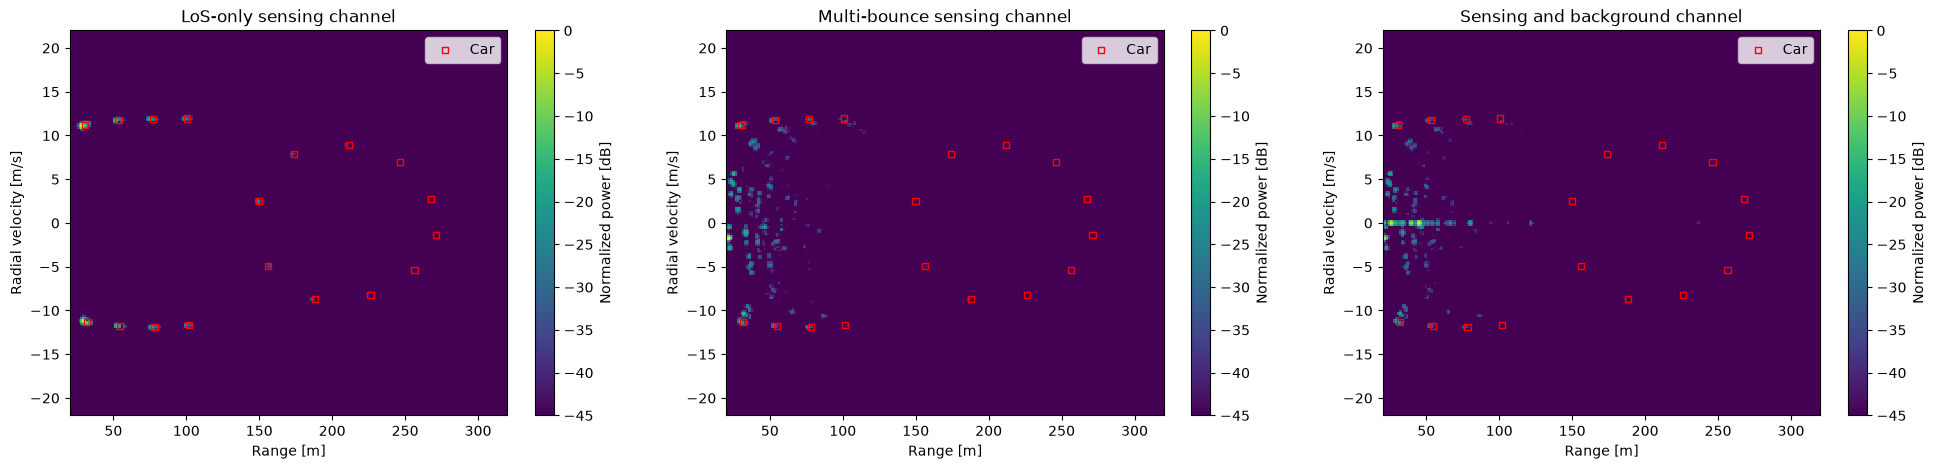

In [20]:
plot_range_velocity_maps(channels, wavelength, car_points,
                         apply_hann_window=True)

The smearing is reduced. However, distant targets appear much weaker than close ones, as the received power decays with $R^4$. Let's compensate for this path loss:

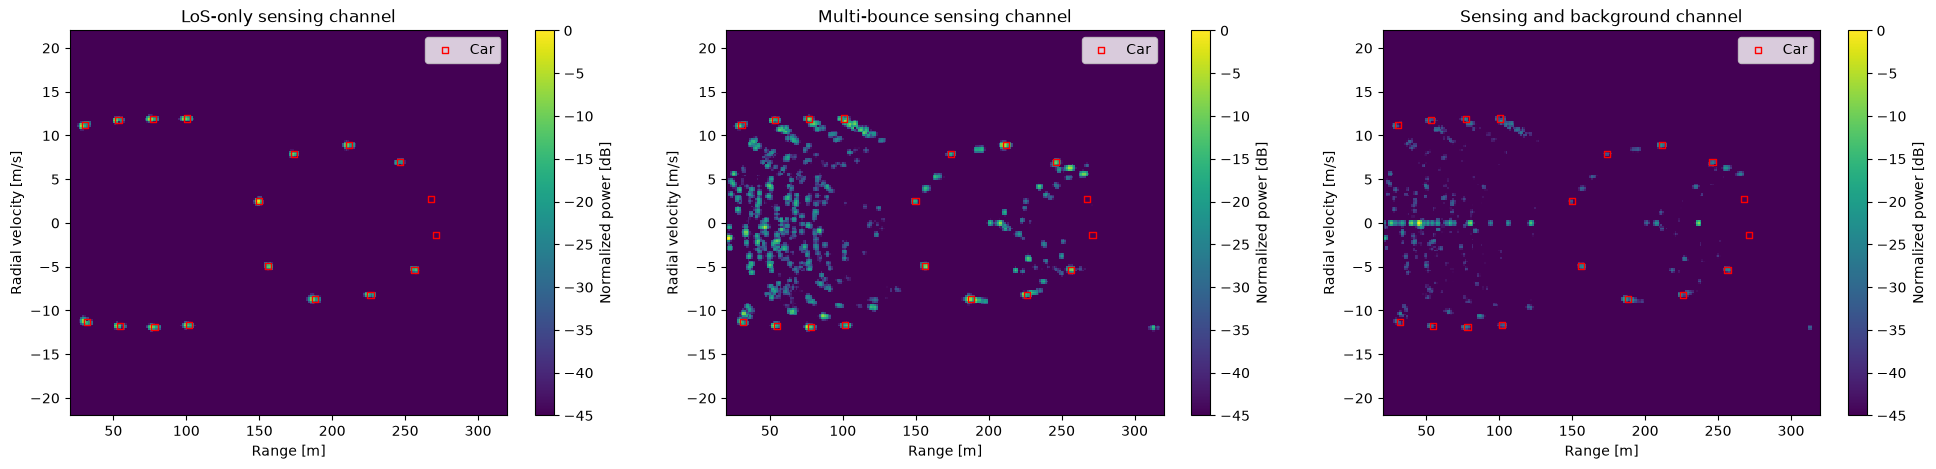

In [21]:
plot_range_velocity_maps(channels, wavelength, car_points,
                         apply_hann_window=True,
                         apply_pathloss_compensation=True)

Distant targets are now clearly visible. However, the multi-bounce sensing channel adds ghost targets, i.e., images of the cars created by reflections on the buildings, which do not match any red square. The background channel adds clutter from the static environment, which appears at zero velocity.

Detecting and localizing the actual targets, e.g., through clutter removal and constant false alarm rate (CFAR) detection, is beyond the scope of this notebook.

## Summary

We have used the `RCSSolver` to compute the radar channel of sensing targets modeled by one or multiple scattering points, validated it against the radar equation, and visualized it in the range-velocity and angular domains. Combined with the background channel computed by the `PathSolver`, it enables the simulation of realistic sensing scenarios with multipath and clutter.

We hope you enjoyed our dive into ISAC with Sionna RT. Don't forget to check out our other [tutorials](https://nvlabs.github.io/sionna/rt/tutorials.html), too.